#**Iterating on Harmony Healthcare Predictions**

Aidan Elizaitis

**Problem Statement**

The goal of this project is to refine the predictive model developed by a group last semester, aiming to improve on their work by selecting variables far more liberally and using a non-linear method of prediction. I've ended up employing random forest because it's very proficient at handling

**Methods**

There is a fairly low number of strictly numerical values in the dataset, so I read through each to choose which to keep as numerical and which should be re-encoded as categorical, with mostly those with 'code' in the name being re-encoded. The data kept as numerical is sorted into groups based upon how best to handle missing values and data is imputed. I've moved imputation to occur after data has been split into testing and training sets to prevent either set impacting how the other imputes values. I didn't have the time to research automated parameter automation so I tinkered with parameters manually instead, settling on an n_estimators of 500 and a max_depth of 50. I did similar manual tinkering to set the threshold since the default classified almost everything as negative.

In [2]:
# We mount our Google drive folder to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load the Harmony HealthCare dataset
HHCData = pd.read_excel('/content/drive/My Drive/Colab Notebooks/Harmony_Healthcare_OneWeek_9_2025.xlsx')

In [19]:
HHCData = pd.concat([HHCData, pd.read_excel('/content/drive/My Drive/Colab Notebooks/9-1 thru 9-7.xlsx')], ignore_index=True)
HHCData = pd.concat([HHCData, pd.read_excel('/content/drive/My Drive/Colab Notebooks/9-8 thru 9-14.xlsx')], ignore_index=True)
HHCData = pd.concat([HHCData, pd.read_excel('/content/drive/My Drive/Colab Notebooks/9-15 thru 9-21.xlsx')], ignore_index=True)

In [20]:
# Data cleaning and preparation

# Remove any completely empty columns
HHCClean = HHCData.dropna(axis='columns', how='all')
print(HHCClean.columns.size, "of", HHCData.columns.size, "variables kept")

# Cast .notna() as int, results in a value for 1 for anything besides nan and 0 for nan
EDBinary = HHCClean['ED Episode Admit Last-6-Mths'].notna().astype(int).values
# Remove all columns with ED in name to avoid them being used in model predictions
HHCClean = HHCClean.drop(columns=HHCClean.filter(like='ED').columns)
# Same with columns with IP in name since inpatient care largely comes after emergency care and often allows the model to see into the future in a way that isn't possible in practical applications
HHCClean = HHCClean.drop(columns=HHCClean.filter(like='IP').columns)
# Insert target variable back into dataframe
HHCClean['EDClaim'] = EDBinary


605 of 708 variables kept


/tmp/ipykernel_4319/3775860930.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  HHCClean['EDClaim'] = EDBinary


In [21]:
# Split target and other columns
X = HHCClean.drop(columns=['EDClaim'])
y = HHCClean['EDClaim']

In [66]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

RF = RandomForestClassifier(n_estimators=500, max_depth=50, class_weight='balanced', random_state=42)

# Set up the 10-fold splitter
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Set up system to take largest auc roc for graphing
bigauc = 0.0

# Prepare lists to get average accuracy and auc roc
acclist = []
auclist = []

# Loop over each split
for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    # Create the sets for THIS specific fold
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    #Independently perform imputation for each training and testing set to prevent crossover
    MedianCols = X_train[['Age', 'CD4 Absolute Result', 'CD4 Absolute Min Result', 'Kidney Profile eGFR Result', 'Risk Score', 'Previous Risk Score', 'LDL Numeric Result',
                       'Urine Microalbumin Result', 'AST Result', 'Most Recent BMI Value', 'Cholesterol Result', 'Patient Medicaid Risk Total Risk', 'Patient Medicaid Risk Risk Gap',
                       'eGFR Result', 'Glucose Test Result', 'Blood Pressure Systolic', 'Blood Pressure Diastolic', 'Household Income Response', 'Household Income Detail', 'LDL Result',
                       'Numeric A1c Result', 'Potassium Serum Result', 'FPL Value', 'Serum Creatinine Result'
                       ]]
    MedianCols = MedianCols.apply(pd.to_numeric, errors='coerce')
    MedianCols = MedianCols.fillna(MedianCols.median())

    ModeCols = X_train[['Active Medications', 'Alcohol Assessment Result', 'GAD-7 Score', 'Dental Encounter Count', 'Depression Screening Count Past Yr', 'Patient HCC Risk Total Risk',
                     'Household Size Response', 'Household Size Detail', 'Patient Appointment No-Show Count', 'Patient Appointment No-Show Rate %', 'Missed Appointment Count',
                     'Missed Appointment Rate %', 'HepA Imm Ct', 'HPV Imm Ct', 'NSAID Rx Refills', 'PHQ-2 Result Value', 'PHQ-9 Result Value', 'Well-Child Visit Counts', 'Primary Care Encounter Count',
                     'SDOH Assessment Count', 'SDOH Tally', 'UDS SDOH Tally', 'UDS Qualifying Encounter Count'
                       ]]
    ModeCols = ModeCols.apply(pd.to_numeric, errors='coerce')
    ModeCols = ModeCols.fillna(ModeCols.mode().iloc[0])

    ZeroCols = X_train[['Behavioral Health Encounter Count', 'Chronic Benzodiazepam Tx Days In Period', 'NSAID Rx Quantity', 'PrEP Rx Quantity', 'PrEP Rx Refills', 'Anticoag Most Recent Rx Quantity',
                     'Anticoag Most Recent Rx Refills', 'Birthweight Detail', 'Chronic Opioid Tx Period Covered Days'
                       ]]
    ZeroCols = ZeroCols.apply(pd.to_numeric, errors='coerce')
    ZeroCols = ZeroCols.fillna(0)

    # Separate datetime as well
    DateCols = X_train.select_dtypes(include=['datetime', 'datetimetz'])
    MissingDates = DateCols.isna().add_suffix('_missing').astype(int)
    for col in DateCols:
      DateCols[col] = (DateCols[col] - pd.Timestamp("1970-01-01")).dt.days
    DateCols = DateCols.fillna(0)

    # Encode all of HHCClean as integer values, filling nan so it can be considered
    X_train = X_train.fillna("Missing")
    X_train = X_train.apply(lambda x: pd.factorize(x)[0])

    # Add data from subcategories back into HHCFilled, add columns for missing dates
    X_train.update(MedianCols)
    X_train.update(ModeCols)
    X_train.update(ZeroCols)
    X_train.update(DateCols)
    X_train = X_train.join(MissingDates)

    MedianCols = X_test[['Age', 'CD4 Absolute Result', 'CD4 Absolute Min Result', 'Kidney Profile eGFR Result', 'Risk Score', 'Previous Risk Score', 'LDL Numeric Result',
                       'Urine Microalbumin Result', 'AST Result', 'Most Recent BMI Value', 'Cholesterol Result', 'Patient Medicaid Risk Total Risk', 'Patient Medicaid Risk Risk Gap',
                       'eGFR Result', 'Glucose Test Result', 'Blood Pressure Systolic', 'Blood Pressure Diastolic', 'Household Income Response', 'Household Income Detail', 'LDL Result',
                       'Numeric A1c Result', 'Potassium Serum Result', 'FPL Value', 'Serum Creatinine Result'
                       ]]
    MedianCols = MedianCols.apply(pd.to_numeric, errors='coerce')
    MedianCols = MedianCols.fillna(MedianCols.median())

    ModeCols = X_test[['Active Medications', 'Alcohol Assessment Result', 'GAD-7 Score', 'Dental Encounter Count', 'Depression Screening Count Past Yr', 'Patient HCC Risk Total Risk',
                     'Household Size Response', 'Household Size Detail', 'Patient Appointment No-Show Count', 'Patient Appointment No-Show Rate %', 'Missed Appointment Count',
                     'Missed Appointment Rate %', 'HepA Imm Ct', 'HPV Imm Ct', 'NSAID Rx Refills', 'PHQ-2 Result Value', 'PHQ-9 Result Value', 'Well-Child Visit Counts', 'Primary Care Encounter Count',
                     'SDOH Assessment Count', 'SDOH Tally', 'UDS SDOH Tally', 'UDS Qualifying Encounter Count'
                       ]]
    ModeCols = ModeCols.apply(pd.to_numeric, errors='coerce')
    ModeCols = ModeCols.fillna(ModeCols.mode().iloc[0])

    ZeroCols = X_test[['Behavioral Health Encounter Count', 'Chronic Benzodiazepam Tx Days In Period', 'NSAID Rx Quantity', 'PrEP Rx Quantity', 'PrEP Rx Refills', 'Anticoag Most Recent Rx Quantity',
                     'Anticoag Most Recent Rx Refills', 'Birthweight Detail', 'Chronic Opioid Tx Period Covered Days'
                       ]]
    ZeroCols = ZeroCols.apply(pd.to_numeric, errors='coerce')
    ZeroCols = ZeroCols.fillna(0)

    # Separate datetime as well
    DateCols = X_test.select_dtypes(include=['datetime', 'datetimetz'])
    MissingDates = DateCols.isna().add_suffix('_missing').astype(int)
    for col in DateCols:
      DateCols[col] = (DateCols[col] - pd.Timestamp("1970-01-01")).dt.days
    DateCols = DateCols.fillna(0)

    # Encode all of HHCClean as integer values, filling nan so it can be considered
    X_test = X_test.fillna("Missing")
    X_test = X_test.apply(lambda x: pd.factorize(x)[0])

    # Add data from subcategories back into HHCFilled, add columns for missing dates
    X_test.update(MedianCols)
    X_test.update(ModeCols)
    X_test.update(ZeroCols)
    X_test.update(DateCols)
    X_test = X_test.join(MissingDates)

    # Train model
    RF.fit(X_train, y_train)

    # Evaluate
    score = RF.score(X_test, y_test)
    probs = RF.predict_proba(X_test)[:, 1]
    threshold = 0.18
    preds = (probs >= threshold).astype(int)
    fold_auc = roc_auc_score(y_test, probs)
    print(f"Fold {fold + 1} Accuracy: {score:.4f}")
    print(f"Fold {fold + 1} ROC: {fold_auc:.4f}")
    print(confusion_matrix(y_test, preds))
    acclist.append(score)
    auclist.append(fold_auc)

    # Finds split with highest ROC
    if fold_auc > bigauc:
      bigauc = fold_auc
      final_Xt = X_train
      final_yt = y_train
      final_Xv = X_test
      final_yv = y_test

print(f"Mean Accuracy: {(sum(acclist)/10):.2f}")
print(f"Mean ROC: {(sum(auclist)/10).mean():.2f}")

Fold 1 Accuracy: 0.9182
Fold 1 ROC: 0.8450
[[951   3]
 [ 45  40]]
Fold 2 Accuracy: 0.9192
Fold 2 ROC: 0.8919
[[950   4]
 [ 35  50]]
Fold 3 Accuracy: 0.9182
Fold 3 ROC: 0.8778
[[950   4]
 [ 43  42]]
Fold 4 Accuracy: 0.9192
Fold 4 ROC: 0.8912
[[946   8]
 [ 35  50]]
Fold 5 Accuracy: 0.9182
Fold 5 ROC: 0.8518
[[945   9]
 [ 44  41]]
Fold 6 Accuracy: 0.9182
Fold 6 ROC: 0.8620
[[951   3]
 [ 39  46]]
Fold 7 Accuracy: 0.9182
Fold 7 ROC: 0.8968
[[945   9]
 [ 30  55]]
Fold 8 Accuracy: 0.9211
Fold 8 ROC: 0.9039
[[947   7]
 [ 36  49]]
Fold 9 Accuracy: 0.9182
Fold 9 ROC: 0.8803
[[949   5]
 [ 37  48]]
Fold 10 Accuracy: 0.9191
Fold 10 ROC: 0.8764
[[948   5]
 [ 44  41]]
Mean Accuracy: 0.92
Mean ROC: 0.88


In [45]:
# Train Model
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(n_estimators=500, max_depth=50, class_weight='balanced', random_state=42)
RF.fit(final_Xt, final_yt)

RandomForestClassifier(class_weight='balanced', max_depth=50, n_estimators=150,
                       random_state=42)

In [49]:
# Test accuracy of model on testing data
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

y_prob = RF.predict_proba(final_Xv)

fpr, tpr, _ = roc_curve(final_yv, y_prob[:, 1])
roc_auc = auc(fpr, tpr)

threshold = 0.18
preds = (y_prob[:, 1] >= threshold).astype(int)

print(f"Accuracy: {accuracy_score(final_yv, preds):.2%}")
print(f"ROC auc: {roc_auc:.2%}")
print(classification_report(final_yv, preds))

Accuracy: 95.48%
ROC auc: 89.79%
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       954
           1       0.81      0.59      0.68        85

    accuracy                           0.95      1039
   macro avg       0.89      0.79      0.83      1039
weighted avg       0.95      0.95      0.95      1039



In [52]:
importances = pd.Series(RF.feature_importances_, index=final_Xt.columns)

sorted_importances = importances.sort_values(ascending=False)
print("10 most predictive variables:")
print(sorted_importances.head(10))

10 most predictive variables:
Patient Appointment No-Show Rate %    0.014594
Patient Medicaid Risk Total Risk      0.012464
Insurance Primary Payer               0.012233
Household Income Date                 0.010941
Blood Pressure Value                  0.010800
Household Size Date                   0.010499
FPL Date                              0.010462
Active Medications                    0.010183
Last Well Care Visit Date             0.009741
UDS Qualifying Encounter Count        0.009635
dtype: float64


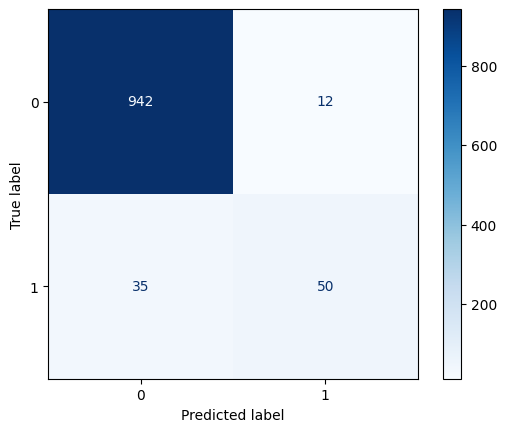

In [59]:
# Create confusion matrix, manually adjusted threshold
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions are made using a manually set threshold since the default gives very poor results
probs = RF.predict_proba(final_Xv)[:, 1]
threshold = 0.18
preds = (probs >= threshold).astype(int)

cmd = ConfusionMatrixDisplay.from_predictions(final_yv, preds, cmap='Blues')

ROC AUC: 0.8979


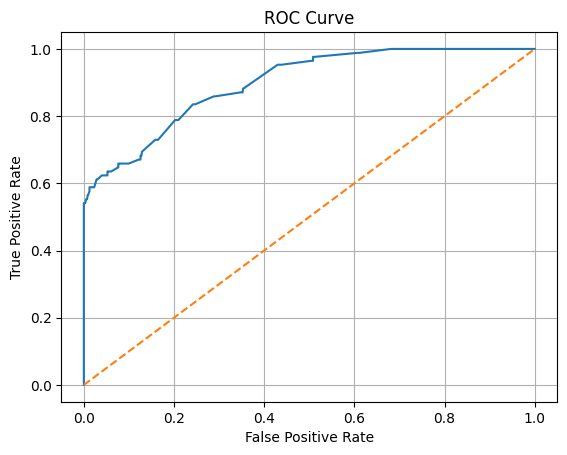

In [67]:
# ROC AUC
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(final_yv, y_prob[:, 1])
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid(True)
plt.show()

**Final Results**

After initially experimenting with a KNN model and finding that the high ratio of false variables to positives in the dataset skewed it too hard I implemented random forest, which both had higher general accuracy and performed better in general. I believe pivoting towards non-linear models like this is the correct way forward, as they are able to handle much higher amounts of data and my current testing consistently yields higher accuracy than the logistic regression model that was employed prior. After recieving more data and adapting the model to use it accuracy increased, leading me to believe accuracy will continue to go up with the addition of more data to work off of. I believe the best next step would be to experiment with neural networks, and possibly to further refine my imputation method.

github link: https://github.com/Pot440/CSC-108-Final_Project